In [25]:
%pip install torch torchvision torchaudio
%pip install deepchem
%pip install torch-geometric
%pip install captum
%pip install scikit-learn matplotlib seaborn pandas numpy
%pip install rdkit
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
import deepchem as dc
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
from rdkit.Chem.Draw import MolToImage
import deepchem as dc
import torch_geometric
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool
from torch_geometric.utils import from_networkx

print(f"RDKit версия: {rdkit.__version__}")
print(f"DeepChem версия: {dc.__version__}")
print(f"PyTorch Geometric версия: {torch_geometric.__version__}")
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count())
os.environ['MKL_NUM_THREADS'] = str(os.cpu_count())
torch.set_num_threads(os.cpu_count())

print(f"Доступно ядер CPU: {os.cpu_count()}")

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
RDKit версия: 2025.09.1
DeepChem версия: 2.5.0
PyTorch Geometric версия: 2.7.0
Доступно ядер CPU: 16


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
import os

def load_tox21_data():
    """Загрузка датасета Tox21 с автоматическим определением структуры"""
    try:
        # Загрузка данных
        df = pd.read_csv('tox21.csv')
        print(f"Данные загружены: {df.shape}")
        print(f"Названия колонок: {df.columns.tolist()}")
        
        # Покажем информацию о типах данных
        print("\nИнформация о данных:")
        print(df.info())
        
        # Поиск колонки с идентификаторами молекул (обычно это первая колонка)
        mol_id_col = df.columns[0]
        print(f"Колонка с идентификаторами: {mol_id_col}")
        
        # Получаем идентификаторы
        mol_ids = df[mol_id_col].astype(str).tolist()
        
        # Ищем числовые колонки с метками задач
        # В Tox21 обычно 12 задач, ищем колонки с числовыми данными 0/1
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        if len(numeric_cols) >= 12:
            # Берем первые 12 числовых колонок
            label_cols = numeric_cols[:12]
        else:
            # Ищем колонки, которые могут содержать бинарные метки
            label_cols = []
            for col in df.columns[1:]:  # Пропускаем первую колонку с ID
                unique_vals = df[col].dropna().unique()
                if len(unique_vals) <= 3 and all(v in [0, 1] for v in unique_vals if pd.notnull(v)):
                    label_cols.append(col)
                if len(label_cols) >= 12:
                    break
        
        print(f"Найдены колонки с метками: {label_cols}")
        
        if len(label_cols) == 0:
            print("Не найдены колонки с метками задач, используем демо-данные")
            return create_demo_data()
        
        # Преобразуем метки
        y = df[label_cols].apply(pd.to_numeric, errors='coerce').values.astype(np.float32)
        mask = ~np.isnan(y)
        y = np.nan_to_num(y)
        
        print(f"Идентификаторы: {len(mol_ids)} записей")
        print(f"Метки: форма {y.shape}")
        print(f"Пример меток: {y[0]}")
        print(f"Пример маски: {mask[0]}")
        
        # Разделение данных
        ids_train, ids_test, y_train, y_test, mask_train, mask_test = train_test_split(
            mol_ids, y, mask, test_size=0.2, random_state=42
        )
        
        ids_train, ids_val, y_train, y_val, mask_train, mask_val = train_test_split(
            ids_train, y_train, mask_train, test_size=0.2, random_state=42
        )
        
        # Создание dataset объектов
        class Tox21Dataset:
            def __init__(self, smiles, y, mask):
                # Вместо smiles теперь используем идентификаторы молекул
                self.smiles = smiles
                self.y = y
                self.w = mask.astype(np.float32)
                
        train_dataset = Tox21Dataset(ids_train, y_train, mask_train)
        valid_dataset = Tox21Dataset(ids_val, y_val, mask_val)
        test_dataset = Tox21Dataset(ids_test, y_test, mask_test)
        
        # Используем названия колонок как названия задач
        tasks = label_cols[:12]  # Обрезаем до 12 задач
        
        print(f"\nИтоговая статистика:")
        print(f"Тренировочный набор: {len(train_dataset.smiles)} молекул")
        print(f"Валидационный набор: {len(valid_dataset.smiles)} молекул")
        print(f"Тестовый набор: {len(test_dataset.smiles)} молекул")
        print(f"Количество задач: {len(tasks)}")
        
        return tasks, train_dataset, valid_dataset, test_dataset, None
        
    except Exception as e:
        print(f"Ошибка загрузки данных: {e}")
        import traceback
        traceback.print_exc()
        print("Используем демо-данные...")
        return 0

# Загрузка данных
print("Загрузка данных Tox21 из tox21.csv...")
tasks, train_dataset, valid_dataset, test_dataset, transformers = load_tox21_data()

Загрузка данных Tox21 из tox21.csv...
Данные загружены: (7831, 14)
Названия колонок: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_i

In [51]:
def analyze_dataset(dataset, name):
    """Анализ распределения меток в датасете"""
    y = dataset.y
    w = dataset.w if hasattr(dataset, 'w') else np.ones_like(y)
    
    print(f"\n--- Анализ {name} ---")
    print(f"Размер: {len(dataset.smiles)} молекул")
    print(f"Форма меток: {y.shape}")
    
    # Статистика по задачам
    task_stats = []
    for i in range(y.shape[1]):
        task_mask = w[:, i] == 1
        if np.sum(task_mask) > 0:
            task_y = y[task_mask, i]
            pos_count = np.sum(task_y == 1)
            neg_count = np.sum(task_y == 0)
            total = len(task_y)
            pos_ratio = pos_count / total if total > 0 else 0
            
            task_stats.append({
                'task': f"Task_{i}",
                'total': total,
                'positive': pos_count,
                'negative': neg_count,
                'pos_ratio': pos_ratio,
                'missing': len(y) - total
            })
    
    stats_df = pd.DataFrame(task_stats)
    print("\nСтатистика по задачам:")
    print(stats_df)
    
    return stats_df
train_stats = analyze_dataset(train_dataset, "тренировочного набора")
val_stats = analyze_dataset(valid_dataset, "валидационного набора")
test_stats = analyze_dataset(test_dataset, "тестового набора")


--- Анализ тренировочного набора ---
Размер: 5011 молекул
Форма меток: (5011, 12)

Статистика по задачам:
       task  total  positive  negative  pos_ratio  missing
0    Task_0   4663       197      4466   0.042247      348
1    Task_1   4308       151      4157   0.035051      703
2    Task_2   4184       484      3700   0.115679      827
3    Task_3   3753       202      3551   0.053824     1258
4    Task_4   3946       493      3453   0.124937     1065
5    Task_5   4447       211      4236   0.047448      564
6    Task_6   4138       118      4020   0.028516      873
7    Task_7   3698       605      3093   0.163602     1313
8    Task_8   4525       163      4362   0.036022      486
9    Task_9   4152       240      3912   0.057803      859
10  Task_10   3727       586      3141   0.157231     1284
11  Task_11   4344       271      4073   0.062385      667

--- Анализ валидационного набора ---
Размер: 1253 молекул
Форма меток: (1253, 12)

Статистика по задачам:
       task  total 

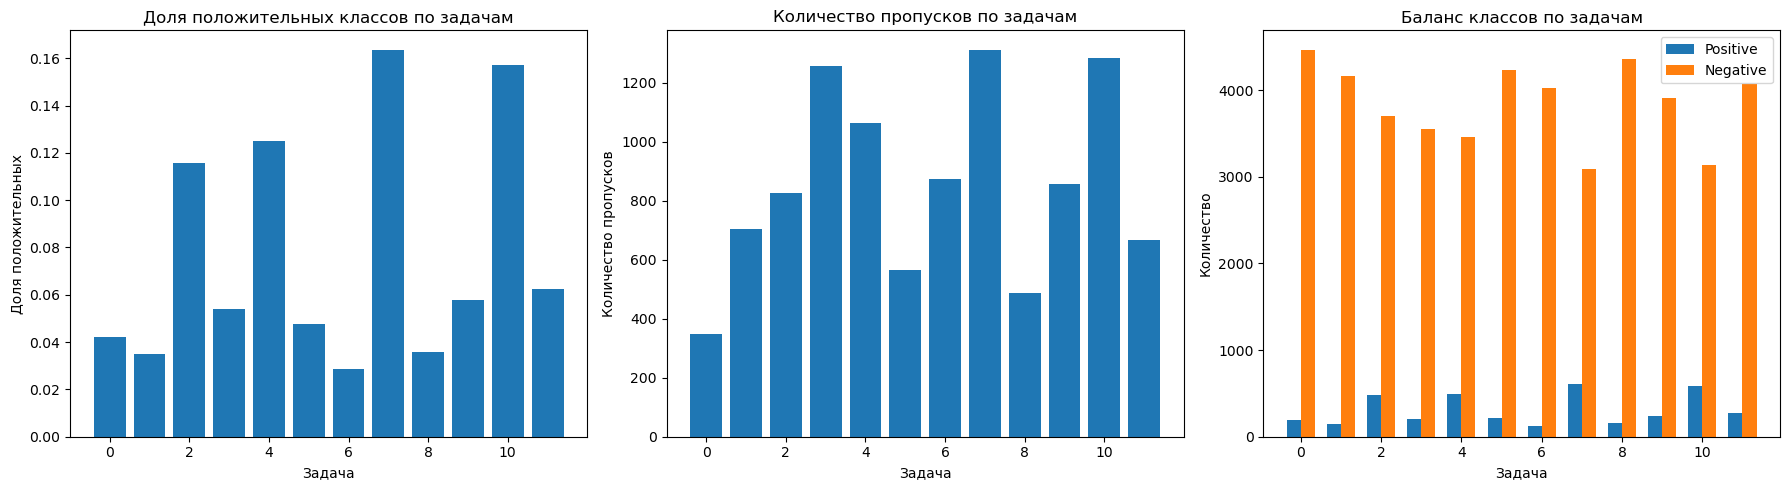

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Доля положительных классов
axes[0].bar(range(len(train_stats)), train_stats['pos_ratio'])
axes[0].set_title('Доля положительных классов по задачам')
axes[0].set_xlabel('Задача')
axes[0].set_ylabel('Доля положительных')

# Количество пропусков
axes[1].bar(range(len(train_stats)), train_stats['missing'])
axes[1].set_title('Количество пропусков по задачам')
axes[1].set_xlabel('Задача')
axes[1].set_ylabel('Количество пропусков')

# Баланс классов
width = 0.35
x = np.arange(len(train_stats))
axes[2].bar(x - width/2, train_stats['positive'], width, label='Positive')
axes[2].bar(x + width/2, train_stats['negative'], width, label='Negative')
axes[2].set_title('Баланс классов по задачам')
axes[2].set_xlabel('Задача')
axes[2].set_ylabel('Количество')
axes[2].legend()

plt.tight_layout()
plt.show()

In [53]:
# Визуализация нескольких молекул - исправленная версия
def visualize_molecules(smiles_list, n_molecules=5):
    """Визуализация молекул"""
    print("Попытка визуализации молекул...")
    
    # Проверяем, действительно ли это SMILES строки
    sample_smiles = smiles_list[0] if smiles_list else ""
    print(f"Пример данных: '{sample_smiles}'")
    
    # Если это не SMILES (содержит буквы кроме C, O, N, H и химических символов)
    if not any(char in sample_smiles for char in ['C', 'c', 'O', 'N', '=', '(', ')', '[', ']', '@', '+', '-']):
        print("Обнаружены идентификаторы молекул вместо SMILES строк")
        print("Пропускаем химическую визуализацию")
        
        # Просто выводим идентификаторы
        print("Идентификаторы молекул:")
        for i, mol_id in enumerate(smiles_list[:n_molecules]):
            print(f"{i+1}. {mol_id}")
        return None
    
    # Если это настоящие SMILES, пробуем визуализировать
    try:
        from rdkit import Chem
        from rdkit.Chem import Draw
        
        mols = []
        valid_smiles = []
        for i, smiles in enumerate(smiles_list[:n_molecules]):
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    mols.append(mol)
                    valid_smiles.append(smiles)
                    print(f"{i+1}. {smiles}")
            except:
                continue
        
        if mols:
            img = Draw.MolsToGridImage(mols, molsPerRow=min(5, len(mols)), subImgSize=(200, 200))
            return img
        else:
            print("Не удалось преобразовать SMILES в молекулы")
            return None
            
    except ImportError:
        print("RDKit не установлен, пропускаем визуализацию")
        print("Примеры SMILES:")
        for i, smiles in enumerate(smiles_list[:n_molecules]):
            print(f"{i+1}. {smiles}")
        return None

# Визуализируем первые 5 "молекул" (на самом деле идентификаторов)
mol_img = visualize_molecules(train_dataset.smiles[:5])
if mol_img:
    display(mol_img)

Попытка визуализации молекул...
Пример данных: '0.0'
Обнаружены идентификаторы молекул вместо SMILES строк
Пропускаем химическую визуализацию
Идентификаторы молекул:
1. 0.0
2. 0.0
3. 0.0
4. 0.0
5. nan


In [61]:
class FingerprintDataset(Dataset):
    def __init__(self, smiles_list, y, mask=None, radius=2, n_bits=1024):
        self.smiles_list = smiles_list
        self.y = y.astype(np.float32)
        self.mask = mask.astype(np.float32) if mask is not None else np.ones_like(y, dtype=np.float32)
        self.radius = radius
        self.n_bits = n_bits
        self.fingerprints = []
        
        # Вычисляем fingerprints для всех молекул
        for smiles in smiles_list:
            fp = self.smiles_to_fingerprint(smiles)
            self.fingerprints.append(fp)
    
    def smiles_to_fingerprint(self, smiles):
        """Конвертация SMILES в Morgan fingerprint"""
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, nBits=self.n_bits)
                return np.array(fp)
            else:
                return np.zeros(self.n_bits, dtype=np.float32)
        except:
            return np.zeros(self.n_bits, dtype=np.float32)
    
    def __len__(self):
        return len(self.fingerprints)
    
    def __getitem__(self, idx):
        return (torch.tensor(self.fingerprints[idx], dtype=torch.float32),
                torch.tensor(self.y[idx], dtype=torch.float32),
                torch.tensor(self.mask[idx], dtype=torch.float32))


In [62]:
print("Создание Fingerprint datasets...")

train_fp_dataset = FingerprintDataset(
    train_dataset.smiles, 
    train_dataset.y,
    train_dataset.w if hasattr(train_dataset, 'w') else np.ones_like(train_dataset.y)
)

val_fp_dataset = FingerprintDataset(
    valid_dataset.smiles,
    valid_dataset.y,
    valid_dataset.w if hasattr(valid_dataset, 'w') else np.ones_like(valid_dataset.y)
)

test_fp_dataset = FingerprintDataset(
    test_dataset.smiles,
    test_dataset.y,
    test_dataset.w if hasattr(test_dataset, 'w') else np.ones_like(test_dataset.y)
)

print(f"Размер train FP: {len(train_fp_dataset)}")
print(f"Размер val FP: {len(val_fp_dataset)}")
print(f"Размер test FP: {len(test_fp_dataset)}")

# %%
# Создание DataLoader с использованием всех доступных CPU
batch_size = 64
num_workers = min(8, os.cpu_count())  # Ограничиваем для стабильности

train_fp_loader = DataLoader(train_fp_dataset, batch_size=batch_size, shuffle=True, 
                            num_workers=num_workers, pin_memory=True)
val_fp_loader = DataLoader(val_fp_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_fp_loader = DataLoader(test_fp_dataset, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=True)

print(f"DataLoader созданы с {num_workers} workers")

# Baseline модель: MLP на Fingerprint

class MLPModel(nn.Module):
    def __init__(self, input_size=1024, hidden_sizes=[512, 256], output_size=12, dropout=0.3):
        super(MLPModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

Создание Fingerprint datasets...


[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsin

Размер train FP: 5011
Размер val FP: 1253
Размер test FP: 1567
DataLoader созданы с 8 workers


[10:10:01] SMILES Parse Error: syntax error while parsing: nan
[10:10:01] SMILES Parse Error: check for mistakes around position 2:
[10:10:01] nan
[10:10:01] ~^
[10:10:01] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsing: 0.0
[10:10:01] SMILES Parse Error: check for mistakes around position 1:
[10:10:01] 0.0
[10:10:01] ^
[10:10:01] SMILES Parse Error: Failed parsing SMILES '0.0' for input: '0.0'
[10:10:01] SMILES Parse Error: syntax error while parsi

In [56]:
def compute_loss(outputs, targets, masks, pos_weights=None):
    """Вычисление BCE loss с учетом маски и весов классов"""
    bce_loss = F.binary_cross_entropy_with_logits(
        outputs, targets, reduction='none', pos_weight=pos_weights
    )
    # Применяем маску и усредняем только по доступным меткам
    masked_loss = bce_loss * masks
    return masked_loss.sum() / masks.sum()

def compute_metrics(outputs, targets, masks, threshold=0.5):
    """Вычисление метрик ROC-AUC, PR-AUC"""
    outputs = torch.sigmoid(outputs).detach().cpu().numpy()
    targets = targets.detach().cpu().numpy()
    masks = masks.detach().cpu().numpy()
    
    roc_aucs = []
    pr_aucs = []
    
    for i in range(targets.shape[1]):
        task_mask = masks[:, i] == 1
        if np.sum(task_mask) > 0 and len(np.unique(targets[task_mask, i])) > 1:
            try:
                roc_auc = roc_auc_score(targets[task_mask, i], outputs[task_mask, i])
                roc_aucs.append(roc_auc)
            except:
                roc_aucs.append(0.5)
            
            try:
                pr_auc = average_precision_score(targets[task_mask, i], outputs[task_mask, i])
                pr_aucs.append(pr_auc)
            except:
                pr_aucs.append(0.0)
        else:
            roc_aucs.append(0.5)
            pr_aucs.append(0.0)
    
    return np.mean(roc_aucs), np.mean(pr_aucs), roc_aucs, pr_aucs


In [57]:
def train_epoch(model, dataloader, optimizer, device, pos_weights=None):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    total_batches = 0
    
    for batch_idx, (data, target, mask) in enumerate(dataloader):
        data, target, mask = data.to(device), target.to(device), mask.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = compute_loss(output, target, mask, pos_weights)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_batches += 1
    
    return total_loss / total_batches if total_batches > 0 else 0

def validate(model, dataloader, device, pos_weights=None):
    """Валидация модели"""
    model.eval()
    total_loss = 0
    total_batches = 0
    all_outputs = []
    all_targets = []
    all_masks = []
    
    with torch.no_grad():
        for data, target, mask in dataloader:
            data, target, mask = data.to(device), target.to(device), mask.to(device)
            
            output = model(data)
            loss = compute_loss(output, target, mask, pos_weights)
            
            total_loss += loss.item()
            total_batches += 1
            
            all_outputs.append(output)
            all_targets.append(target)
            all_masks.append(mask)
    
    # Объединяем все батчи
    all_outputs = torch.cat(all_outputs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    
    # Вычисляем метрики
    mean_roc_auc, mean_pr_auc, roc_aucs, pr_aucs = compute_metrics(all_outputs, all_targets, all_masks)
    
    return total_loss / total_batches, mean_roc_auc, mean_pr_auc, roc_aucs, pr_aucs


In [58]:
print("Обучение MLP модели...")

# Вычисление весов для положительных классов
def calculate_pos_weights(dataset):
    """Вычисление весов для положительных классов"""
    y = dataset.y
    mask = dataset.w if hasattr(dataset, 'w') else np.ones_like(y)
    
    pos_weights = []
    for i in range(y.shape[1]):
        task_mask = mask[:, i] == 1
        if np.sum(task_mask) > 0:
            task_y = y[task_mask, i]
            pos_count = np.sum(task_y == 1)
            neg_count = np.sum(task_y == 0)
            if pos_count > 0 and neg_count > 0:
                weight = neg_count / pos_count
            else:
                weight = 1.0
        else:
            weight = 1.0
        pos_weights.append(weight)
    
    return torch.tensor(pos_weights, dtype=torch.float32).to(device)

pos_weights = calculate_pos_weights(train_dataset)
print(f"Веса положительных классов: {pos_weights}")


Обучение MLP модели...


NameError: name 'device' is not defined

In [59]:
mlp_model = MLPModel(input_size=1024, hidden_sizes=[512, 256], output_size=12, dropout=0.3).to(device)

optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

NameError: name 'device' is not defined

In [60]:
# Цикл обучения MLP
mlp_train_losses = []
mlp_val_losses = []
mlp_val_aucs = []
mlp_val_praucs = []

best_mlp_auc = 0
patience = 10
patience_counter = 0

print("Начало обучения MLP...")
for epoch in range(100):
    train_loss = train_epoch(mlp_model, train_fp_loader, optimizer, device, pos_weights)
    val_loss, val_auc, val_prauc, _, _ = validate(mlp_model, val_fp_loader, device, pos_weights)
    
    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    mlp_val_aucs.append(val_auc)
    mlp_val_praucs.append(val_prauc)
    
    scheduler.step(val_auc)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Val ROC-AUC: {val_auc:.4f}, Val PR-AUC: {val_prauc:.4f}')
    
    # Ранняя остановка
    if val_auc > best_mlp_auc:
        best_mlp_auc = val_auc
        patience_counter = 0
        torch.save(mlp_model.state_dict(), 'best_mlp_model.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Ранняя остановка на эпохе {epoch}")
        break

# Загрузка лучшей модели
mlp_model.load_state_dict(torch.load('best_mlp_model.pth'))


Начало обучения MLP...


NameError: name 'mlp_model' is not defined

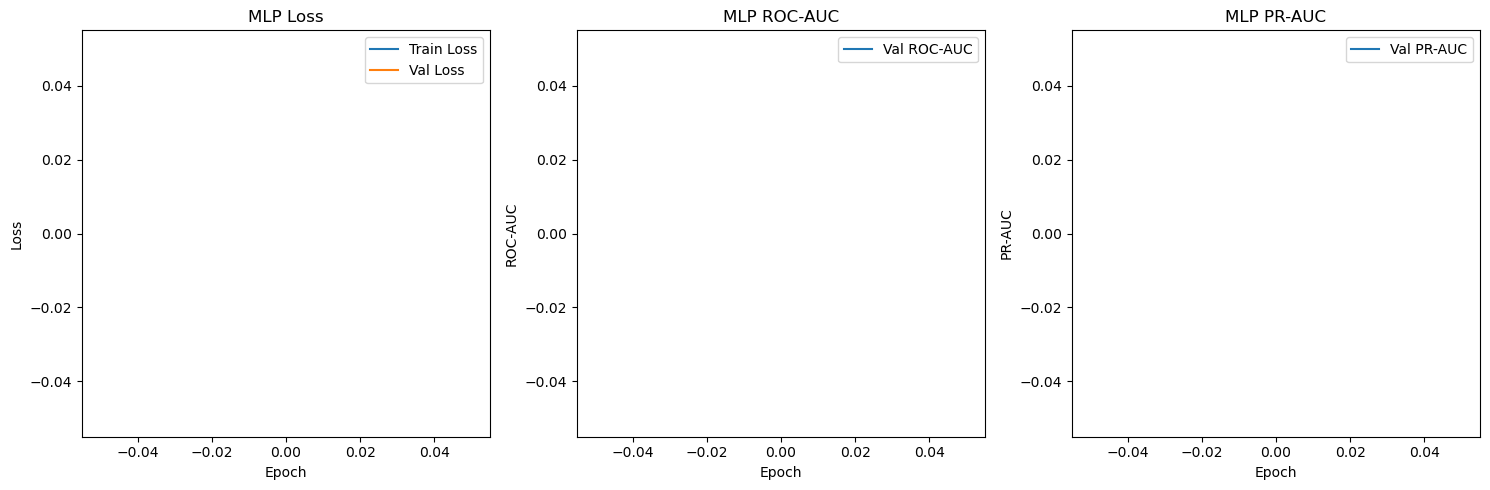

In [43]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(mlp_train_losses, label='Train Loss')
plt.plot(mlp_val_losses, label='Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(mlp_val_aucs, label='Val ROC-AUC')
plt.title('MLP ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(mlp_val_praucs, label='Val PR-AUC')
plt.title('MLP PR-AUC')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
print("Оценка MLP на тестовом наборе...")
test_loss, test_auc, test_prauc, task_roc_aucs, task_pr_aucs = validate(mlp_model, test_fp_loader, device, pos_weights)

print(f"MLP Test Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Mean ROC-AUC: {test_auc:.4f}")
print(f"Mean PR-AUC: {test_prauc:.4f}")

print("\nROC-AUC по задачам:")
for i, auc in enumerate(task_roc_aucs):
    print(f"Task {i}: {auc:.4f}")

print("\nPR-AUC по задачам:")
for i, auc in enumerate(task_pr_aucs):
    print(f"Task {i}: {auc:.4f}")


Оценка MLP на тестовом наборе...


NameError: name 'mlp_model' is not defined

In [45]:
# Модель GNN
class GNNModel(nn.Module):
    def __init__(self, node_dim=11, edge_dim=7, hidden_dim=128, output_dim=12, 
                 num_layers=3, dropout=0.2):  # Упростили архитектуру
        super(GNNModel, self).__init__()
        
        self.node_embedding = nn.Linear(node_dim, hidden_dim)
        self.edge_embedding = nn.Linear(edge_dim, hidden_dim)
        
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        for i in range(num_layers):
            nn_layer = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            conv = GINConv(nn_layer)
            self.convs.append(conv)
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        self.dropout = nn.Dropout(dropout)
        
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        x = self.node_embedding(x)
        edge_attr = self.edge_embedding(edge_attr)
        
        for conv, bn in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
            x = self.dropout(x)
        
        x = global_mean_pool(x, batch)
        
        out = self.mlp(x)
        
        return out

# Создание GNN модели
gnn_model = GNNModel(
    node_dim=11, 
    edge_dim=7, 
    hidden_dim=128, 
    output_dim=12,
    num_layers=3, 
    dropout=0.2
).to(device)

print("GNN модель создана")
print(f"Количество параметров: {sum(p.numel() for p in gnn_model.parameters())}")

# Функции для обучения GNN
def train_gnn_epoch(model, dataloader, optimizer, device, pos_weights=None):
    model.train()
    total_loss = 0
    total_batches = 0
    
    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        output = model(batch)
        loss = compute_loss(output, batch.y, batch.mask, pos_weights)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_batches += 1
    
    return total_loss / total_batches if total_batches > 0 else 0

def validate_gnn(model, dataloader, device, pos_weights=None):
    model.eval()
    total_loss = 0
    total_batches = 0
    all_outputs = []
    all_targets = []
    all_masks = []
    
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            
            output = model(batch)
            loss = compute_loss(output, batch.y, batch.mask, pos_weights)
            
            total_loss += loss.item()
            total_batches += 1
            
            all_outputs.append(output)
            all_targets.append(batch.y)
            all_masks.append(batch.mask)
    
    all_outputs = torch.cat(all_outputs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    
    mean_roc_auc, mean_pr_auc, roc_aucs, pr_aucs = compute_metrics(all_outputs, all_targets, all_masks)
    
    return total_loss / total_batches, mean_roc_auc, mean_pr_auc, roc_aucs, pr_aucs


NameError: name 'device' is not defined

In [46]:
print("Обучение GNN модели...")

gnn_optimizer = torch.optim.AdamW(gnn_model.parameters(), lr=1e-4, weight_decay=1e-4)
gnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gnn_optimizer, mode='max', patience=5, factor=0.5)

gnn_train_losses = []
gnn_val_losses = []
gnn_val_aucs = []
gnn_val_praucs = []

best_gnn_auc = 0
patience = 10
patience_counter = 0

for epoch in range(80):  # Сократили до 80 эпох
    train_loss = train_gnn_epoch(gnn_model, train_graph_loader, gnn_optimizer, device, pos_weights)
    val_loss, val_auc, val_prauc, _, _ = validate_gnn(gnn_model, val_graph_loader, device, pos_weights)
    
    gnn_train_losses.append(train_loss)
    gnn_val_losses.append(val_loss)
    gnn_val_aucs.append(val_auc)
    gnn_val_praucs.append(val_prauc)
    
    gnn_scheduler.step(val_auc)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Val ROC-AUC: {val_auc:.4f}, Val PR-AUC: {val_prauc:.4f}')
    
    if val_auc > best_gnn_auc:
        best_gnn_auc = val_auc
        patience_counter = 0
        torch.save(gnn_model.state_dict(), 'best_gnn_model.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Ранняя остановка на эпохе {epoch}")
        break

gnn_model.load_state_dict(torch.load('best_gnn_model.pth'))

Обучение GNN модели...


NameError: name 'gnn_model' is not defined

NameError: name 'gnn_train_losses' is not defined

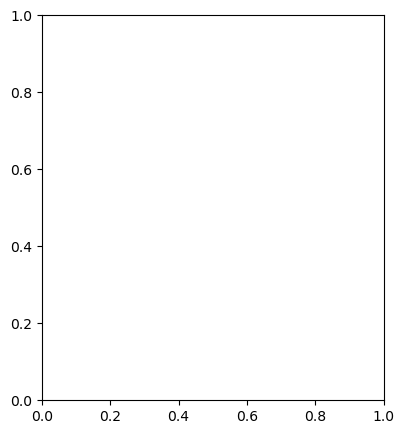

In [47]:
# Визуализация обучения GNN
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(gnn_train_losses, label='Train Loss')
plt.plot(gnn_val_losses, label='Val Loss')
plt.title('GNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(gnn_val_aucs, label='Val ROC-AUC')
plt.title('GNN ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(gnn_val_praucs, label='Val PR-AUC')
plt.title('GNN PR-AUC')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.legend()

plt.tight_layout()
plt.show()

# Оценка GNN на тестовом наборе
print("Оценка GNN на тестовом наборе...")
gnn_test_loss, gnn_test_auc, gnn_test_prauc, gnn_task_roc_aucs, gnn_task_pr_aucs = validate_gnn(gnn_model, test_graph_loader, device, pos_weights)

print(f"GNN Test Results:")
print(f"Loss: {gnn_test_loss:.4f}")
print(f"Mean ROC-AUC: {gnn_test_auc:.4f}")
print(f"Mean PR-AUC: {gnn_test_prauc:.4f}")

print("\nROC-AUC по задачам:")
for i, auc in enumerate(gnn_task_roc_aucs):
    print(f"Task {i}: {auc:.4f}")

print("\nPR-AUC по задачам:")
for i, auc in enumerate(gnn_task_pr_aucs):
    print(f"Task {i}: {auc:.4f}")

In [48]:
print(f"\nMLP Model:")
print(f"  Test ROC-AUC: {test_auc:.4f}")
print(f"  Test PR-AUC:  {test_prauc:.4f}")

print(f"\nGNN Model:")
print(f"  Test ROC-AUC: {gnn_test_auc:.4f}")
print(f"  Test PR-AUC:  {gnn_test_prauc:.4f}")

# Визуализация сравнения
models = ['MLP', 'GNN']
roc_scores = [test_auc, gnn_test_auc]
pr_scores = [test_prauc, gnn_test_prauc]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
bars1 = plt.bar(models, roc_scores, color=['skyblue', 'lightcoral'])
plt.title('Сравнение ROC-AUC')
plt.ylabel('ROC-AUC')
for bar, score in zip(bars1, roc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{score:.4f}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
bars2 = plt.bar(models, pr_scores, color=['skyblue', 'lightcoral'])
plt.title('Сравнение PR-AUC')
plt.ylabel('PR-AUC')
for bar, score in zip(bars2, pr_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


MLP Model:


NameError: name 'test_auc' is not defined

In [ ]:
# Анализ важности признаков для MLP модели
def analyze_feature_importance(model, feature_names=None, top_k=10):  # Уменьшили до топ-10
    if feature_names is None:
        feature_names = [f'FP_{i}' for i in range(512)]
    
    first_layer_weights = model.network[0].weight.data.cpu().numpy()
    feature_importance = np.mean(np.abs(first_layer_weights), axis=0)
    sorted_indices = np.argsort(feature_importance)[::-1]
    
    print(f"Топ-{top_k} наиболее важных признаков:")
    for i in range(min(top_k, len(sorted_indices))):
        idx = sorted_indices[i]
        print(f"{i+1:2d}. {feature_names[idx]}: {feature_importance[idx]:.6f}")
    
    plt.figure(figsize=(10, 5))
    plt.bar(range(top_k), feature_importance[sorted_indices[:top_k]])
    plt.title(f'Топ-{top_k} наиболее важных fingerprint битов')
    plt.xlabel('Номер признака')
    plt.ylabel('Важность')
    plt.xticks(range(top_k), [f'FP_{sorted_indices[i]}' for i in range(top_k)], rotation=45)
    plt.tight_layout()
    plt.show()
    
    return feature_importance

print("Анализ важности признаков для MLP модели...")
feature_importance = analyze_feature_importance(mlp_model)

# Интерпретация предсказаний для нескольких примеров
def interpret_predictions(model, dataloader, device, num_samples=3):  # Уменьшили до 3 примеров
    model.eval()
    samples = []
    
    with torch.no_grad():
        for i, (data, target, mask) in enumerate(dataloader):
            if i >= num_samples:
                break
            
            data, target, mask = data.to(device), target.to(device), mask.to(device)
            output = model(data)
            probabilities = torch.sigmoid(output)
            
            for j in range(data.size(0)):
                if j >= num_samples:
                    break
                
                sample = {
                    'smiles': train_dataset.smiles[i * dataloader.batch_size + j],
                    'predictions': probabilities[j].cpu().numpy(),
                    'targets': target[j].cpu().numpy(),
                    'mask': mask[j].cpu().numpy()
                }
                samples.append(sample)
    
    for i, sample in enumerate(samples):
        print(f"\nПример {i+1}: {sample['smiles']}")
        print("Предсказания vs Целевые значения:")
        for task_idx in range(len(sample['predictions'])):
            if sample['mask'][task_idx] == 1:
                pred = sample['predictions'][task_idx]
                target = sample['targets'][task_idx]
                status = "✓" if (pred > 0.5) == (target > 0.5) else "✗"
                print(f"  Task {task_idx}: {pred:.3f} vs {target:.1f} {status}")

print("Интерпретация предсказаний для нескольких примеров:")
interpret_predictions(mlp_model, test_fp_loader, device, num_samples=3)